# TFG V4 — Cost-phase + local mixer

This version implements a simple variational strategy to increase the probability of measuring valid windows without using Grover. The idea is to assign a phase according to each window cost and then mix amplitude only between neighboring indices.

## Represented problem

- `0`: free cell.
- `1`: occupied cell.
- Each index `i` represents a valid starting position for a window `M` inside the grid `N`.
- A window is valid if all its cells are `0`.

For each index, define:

```text
C(i) = number of ones in window_i
```

therefore `C(i)=0` means that the window is valid.

## Circuit flow

1. Prepare a uniform superposition over window indices.
2. Reversibly load `window_i` into the register `m`.
3. Apply a cost-dependent phase: each `1` bit in the window contributes a phase `theta`.
4. Uncompute `window_i` so that the phase remains encoded on `idx`.
5. Apply a local mixer on `idx`, usually between geometrically neighboring windows.
6. Repeat the block several times.

## Main registers

- `n`: fixed grid.
- `idx`: index of the candidate window.
- `m`: window temporarily loaded to compute the phase.

## Purpose of this version

V4 studies whether the `cost-phase + mixer` block concentrates amplitude on windows with `C(i)=0`. The code is modular so that the mixer, the parameters `theta`, `mixer_angle`, `repetitions`, and the 1D/2D/ND geometry can be changed easily.

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import numpy as np
import qiskit

from math import prod
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import MCXGate, UnitaryGate

print(qiskit.__version__)

2.3.1


In [3]:
# =========================================================
# Configurable parameters for the main experiment
# =========================================================

N = [8]          # grid size per dimension
M = [2]          # window/job size per dimension
occupied_coords = [(0), (3), (4), (5)]  # occupied coordinates (0-based)

# Cost-phase + mixer block
theta = np.pi / 6   # tuned value for the current main 1D case
mixer_angle = 0.30  # tuned value to increase P_valid in the main case
repetitions = 4
use_cost_phase = True
use_mixer = True

# Available mixers:
# - "local_geometric": rotates between neighboring valid windows in the ND geometry
# - "linear_valid": rotates between consecutive valid indices
# - "rx_all": simple prototype with RX on all idx bits; it can leak amplitude to invalid indices
mixer_method = "local_geometric"

## Tuned parameters for the main example

The main example uses a small 1D grid so that the circuit is easy to inspect and simulate:

```python
N = [8]
M = [2]
occupied_coords = [0, 3, 4, 5]
```

In this case there are `W=7` possible windows and two valid windows. With the current parameters:

```python
theta = np.pi / 6
mixer_angle = 0.30
repetitions = 4
```

Statevector simulation increases the total probability of measuring a valid window from approximately `0.2857` to `0.8981`.

These values are specific to the example. If the grid, window size, or mixer changes, the parameters should be swept again because the dynamics are oscillatory: too many repetitions can move amplitude back to invalid indices.

In [4]:
# =========================================================
# ND geometry and classical utilities
# =========================================================

def validate_problem(N, M):
    if len(N) != len(M):
        raise ValueError("N and M must have the same dimension.")
    for d, (n_d, m_d) in enumerate(zip(N, M)):
        if n_d <= 0 or m_d <= 0:
            raise ValueError(f"N[{d}] and M[{d}] must be positive.")
        if m_d > n_d:
            raise ValueError(f"M[{d}] cannot be greater than N[{d}].")


def coord_to_index(coord, dims):
    """Converts ND coordinates to a row-major linear index.
    Example with dims = [4,4]:
    (0,0) -> 0    (0,1) -> 1    (0,2) -> 2    (0,3) -> 3
    (1,0) -> 4    (1,1) -> 5    (1,2) -> 6    (1,3) -> 7
    (2,0) -> 8    (2,1) -> 9    (2,2) -> 10   (2,3) -> 11
    (3,0) -> 12   (3,1) -> 13   (3,2) -> 14   (3,3) -> 15
    """
    idx_lin = 0
    stride = 1
    for d in reversed(range(len(dims))):
        idx_lin += coord[d] * stride
        stride *= dims[d]
    return idx_lin


def index_to_coord(index, dims):
    """Converts a row-major linear index to ND coordinates.
    Example with dims = [4,4]:
    0 -> (0,0)    1 -> (0,1)    2 -> (0,2)    3 -> (0,3)
    4 -> (1,0)    5 -> (1,1)    6 -> (1,2)    7 -> (1,3)
    8 -> (2,0)    9 -> (2,1)    10 -> (2,2)   11 -> (2,3)
    12 -> (3,0)   13 -> (3,1)    14 -> (3,2)   15 -> (3,3)
    """
    coord = [0] * len(dims)
    rem = index
    for d in reversed(range(len(dims))):
        coord[d] = rem % dims[d]
        rem //= dims[d]
    return tuple(coord)


def valid_starts_nd(N, M):
    """Valid starting coordinates for a window M inside N."""
    return list(np.ndindex(tuple(N[d] - M[d] + 1 for d in range(len(N)))))


def window_qubits_nd(start, N, M):
    """Linear indices of the cells covered by the window starting at start."""
    qubits = []
    for offset in np.ndindex(tuple(M)):
        coord = tuple(start[d] + offset[d] for d in range(len(N)))
        qubits.append(coord_to_index(coord, N))
    return qubits


def normalize_coord(coord, D):
    if D == 1 and isinstance(coord, int):
        return (coord,)
    return tuple(coord)


def build_grid_bits(N, occupied_coords):
    """Returns a classical vector with 1 on occupied cells and 0 on free cells."""
    D = len(N)
    grid = [0] * prod(N)
    for raw_coord in occupied_coords:
        coord = normalize_coord(raw_coord, D)
        if len(coord) != D:
            raise ValueError(f"Coordinate {coord} does not have dimension {D}.")
        for d, x in enumerate(coord):
            if x < 0 or x >= N[d]:
                raise ValueError(f"Coordinate {coord} is outside the grid N={N}.")
        grid[coord_to_index(coord, N)] = 1
    return grid


def compute_window_cost_classical(grid_bits, start, N, M):
    """C(i): number of ones in the window associated with start."""
    return sum(grid_bits[q] for q in window_qubits_nd(start, N, M))


def window_string_classical(grid_bits, start, N, M):
    return ''.join(str(grid_bits[q]) for q in window_qubits_nd(start, N, M))


def get_valid_indices(grid_bits, starts, N, M):
    return [i for i, start in enumerate(starts) if compute_window_cost_classical(grid_bits, start, N, M) == 0]


def gray_order_valid(W, IDX):
    """
    000 -> 0
    001 -> 1
    011 -> 3
    010 -> 2
    110 -> 6
    111 -> 7
    101 -> 5
    100 -> 4
    """
    gray_full = [t ^ (t >> 1) for t in range(2**IDX)]
    return [g for g in gray_full if g < W]


def format_nd_array_from_bits(bitstring, dims):
    arr = np.array(list(bitstring), dtype=str).reshape(tuple(dims))
    return np.array2string(arr, separator=' ').replace("'", "")

In [5]:
# =========================================================
# Quantum blocks: reversible loader, cost phase, and mixers
# =========================================================

def append_mcx(qc, controls, target):
    """Modern MCX through MCXGate, without deprecated arguments such as mode='noancilla'."""
    if len(controls) == 0:
        qc.x(target)
    elif len(controls) == 1:
        qc.cx(controls[0], target)
    else:
        qc.append(MCXGate(num_ctrl_qubits=len(controls)), controls + [target])

def apply_window_loader(qc, n, idx, m, starts, N, M, order_valid):
    """
    Implements L: |grid>|i>|m> -> |grid>|i>|m xor window_i>.
    Applying this function twice uncomputes the window because the block is reversible XOR.
    """
    IDX = len(idx)
    current_zero_mask = [False] * IDX

    for i in order_valid:
        bits = [(i >> b) & 1 for b in range(IDX)]  # little-endian en Qiskit
        target_zero_mask = [bits[b] == 0 for b in range(IDX)]

        for b in range(IDX):
            if current_zero_mask[b] != target_zero_mask[b]:
                qc.x(idx[b])
                current_zero_mask[b] = target_zero_mask[b]

        for j, n_pos in enumerate(window_qubits_nd(starts[i], N, M)):
            controls = [idx[b] for b in range(IDX)] + [n[n_pos]]
            append_mcx(qc, controls, m[j])

    for b in range(IDX):
        if current_zero_mask[b]:
            qc.x(idx[b])


def apply_cost_phase(qc, m, theta):
    """
    If m contains window_i, then each qubit m[j]=1 accumulates phase exp(i theta).
    El estado |window_i> acumula exp(i theta C(i)).
    """
    for q in m:
        qc.p(theta, q)


def two_level_mixer_gate(num_qubits, a, b, beta, label=None):
    """
    Local rotation in the subspace span{|a>, |b>}:
        exp(-i beta X_ab)
    and identity action on the rest. This is a modular prototype for small graphs.
    """
    dim = 2**num_qubits
    U = np.eye(dim, dtype=complex)
    c = np.cos(beta)
    s = -1j * np.sin(beta)
    U[a, a] = c
    U[b, b] = c
    U[a, b] = s
    U[b, a] = s
    return UnitaryGate(U, label=label or f"Mix({a},{b})")


def mixer_edges_from_starts(starts, N, method="local_geometric"):
    """Local edges between valid indices. Does not implement Grover global diffusion."""
    if method == "linear_valid":
        return [(i, i + 1) for i in range(len(starts) - 1)]

    if method != "local_geometric":
        raise ValueError("Unknown local mixer method.")

    start_to_idx = {tuple(s): i for i, s in enumerate(starts)}
    edges = []
    D = len(N)
    for i, start in enumerate(starts):
        for d in range(D):
            neigh = list(start)
            neigh[d] += 1
            neigh = tuple(neigh)
            if neigh in start_to_idx:
                edges.append((i, start_to_idx[neigh]))
    return edges


def apply_mixer(qc, idx, starts, N, mixer_angle, method="local_geometric"):
    """
    Modular mixer on the idx register.
    - local_geometric: mixes neighboring windows in the geometry of starts.
    - linear_valid: mixes consecutive valid indices.
    - rx_all: simple prototype; can transfer amplitude to invalid indices if W is not a power of 2.
    """
    if abs(mixer_angle) < 1e-15:
        return

    if method == "rx_all":
        for q in idx:
            qc.rx(2 * mixer_angle, q)
        return

    IDX = len(idx)
    for a, b in mixer_edges_from_starts(starts, N, method):
        qc.append(two_level_mixer_gate(IDX, a, b, mixer_angle), list(idx))

In [11]:
# =========================================================
# Circuit construction and probability analysis
# =========================================================

def prepare_valid_index_superposition(qc, idx, W):
    IDX = len(idx)
    amps = np.zeros(2**IDX, dtype=complex)
    amps[:W] = 1 / np.sqrt(W)
    qc.initialize(amps, idx)


def prepare_grid_register(qc, n, N, occupied_coords):
    for q in [coord_to_index(normalize_coord(c, len(N)), N) for c in occupied_coords]:
        qc.x(n[q])


def build_cost_phase_mixer_circuit(
    N, M, occupied_coords, theta, mixer_angle, repetitions,
    use_cost_phase=True, use_mixer=True, mixer_method="local_geometric",
    add_barriers=True,
):
    validate_problem(N, M)
    D = len(N)
    N_tot = prod(N)
    M_tot = prod(M)
    starts = valid_starts_nd(N, M)
    W = len(starts)
    IDX = int(np.ceil(np.log2(W))) if W > 1 else 1
    order_valid = gray_order_valid(W, IDX)
    grid_bits = build_grid_bits(N, occupied_coords)

    n = QuantumRegister(N_tot, "n")
    idx = QuantumRegister(IDX, "i")
    m = QuantumRegister(M_tot, "m")
    qc = QuantumCircuit(n, idx, m)

    prepare_grid_register(qc, n, N, occupied_coords)
    prepare_valid_index_superposition(qc, idx, W)
    if add_barriers:
        qc.barrier()

    for r in range(repetitions):
        apply_window_loader(qc, n, idx, m, starts, N, M, order_valid)
        if use_cost_phase:
            apply_cost_phase(qc, m, theta)
        apply_window_loader(qc, n, idx, m, starts, N, M, order_valid)
        if use_mixer:
            apply_mixer(qc, idx, starts, N, mixer_angle, mixer_method)
        if add_barriers:
            qc.barrier()  # end of cost-phase + mixer layer

    metadata = {
        "D": D, "N": list(N), "M": list(M), "N_tot": N_tot, "M_tot": M_tot,
        "starts": starts, "W": W, "IDX": IDX, "grid_bits": grid_bits,
        "occupied_coords": [normalize_coord(c, D) for c in occupied_coords],
        "theta": theta, "mixer_angle": mixer_angle, "repetitions": repetitions,
        "mixer_method": mixer_method,
    }
    return qc, metadata


def index_probabilities_from_statevector(sv, metadata):
    N_tot = metadata["N_tot"]
    IDX = metadata["IDX"]
    probs = np.zeros(2**IDX, dtype=float)
    idx_mask = (1 << IDX) - 1
    for basis_idx, amp in enumerate(sv.data):
        prob = float(abs(amp) ** 2)
        if prob == 0.0:
            continue
        idx_int = (basis_idx >> N_tot) & idx_mask
        probs[idx_int] += prob
    return probs


def analyze_probabilities(sv, metadata, title="Analysis", tol=1e-12):
    N, M = metadata["N"], metadata["M"]
    starts = metadata["starts"]
    W = metadata["W"]
    grid_bits = metadata["grid_bits"]
    probs = index_probabilities_from_statevector(sv, metadata)
    valid_indices = get_valid_indices(grid_bits, starts, N, M)

    p_valid_initial = len(valid_indices) / W
    p_invalid_initial = 1.0 - p_valid_initial
    p_valid_after = float(sum(probs[i] for i in valid_indices))
    p_invalid_after = 1.0 - p_valid_after
    p_invalid_index = float(sum(probs[i] for i in range(W, len(probs))))

    print(f"\n============ {title} ============")
    print(f"N={N}, M={M}, W={W}, IDX={metadata['IDX']}")
    print(f"theta={metadata['theta']:.6g}, mixer_angle={metadata['mixer_angle']:.6g}, repetitions={metadata['repetitions']}")
    print(f"mixer_method={metadata['mixer_method']}")
    print(f"valid_indices={valid_indices}")
    print(f"P_valid_initial = {p_valid_initial:.6f}")
    print(f"P_invalid_initial = {p_invalid_initial:.6f}")
    print(f"P_valid_after   = {p_valid_after:.6f}")
    print(f"P_invalid_after = {p_invalid_after:.6f}")
    if p_invalid_index > tol:
        print(f"P_invalid_index_states = {p_invalid_index:.6f}")

    print("\nindex | start coordinate | window | C(i) | probability | valid")
    print("------|------------------|--------|------|-------------|------")
    rows = []
    for i, start in enumerate(starts):
        window = window_string_classical(grid_bits, start, N, M)
        cost = compute_window_cost_classical(grid_bits, start, N, M)
        rows.append((i, start, window, cost, probs[i]))
        print(f"{i:5d} | {str(start):16s} | {window:6s} | {cost:4d} | {probs[i]:11.6f} | {cost == 0}")

    return {
        "probs": probs,
        "valid_indices": valid_indices,
        "P_valid_initial": p_valid_initial,
        "P_invalid_initial": p_invalid_initial,
        "P_valid_after": p_valid_after,
        "P_invalid_after": p_invalid_after,
        "P_invalid_index_states": p_invalid_index,
        "rows": rows,
    }


def run_experiment(name, N, M, occupied_coords, theta=np.pi, mixer_angle=0.35, repetitions=2,
                   mixer_method="local_geometric", draw=False):
    print(f"\n\n########################################")
    print(f"Experiment: {name}")
    print(f"########################################")
    qc, metadata = build_cost_phase_mixer_circuit(
        N=N, M=M, occupied_coords=occupied_coords,
        theta=theta, mixer_angle=mixer_angle, repetitions=repetitions,
        use_cost_phase=use_cost_phase, use_mixer=use_mixer,
        mixer_method=mixer_method,
    )
    sv = Statevector(qc)
    analysis = analyze_probabilities(sv, metadata, title=name)
    if draw:
        display(qc.draw(output="mpl"))
    return qc, metadata, analysis

## Small tests

These tests are not formal unit tests: they are small cases used to inspect whether the valid probability increases or decreases when changing `theta`, `mixer_angle`, `repetitions`, and `mixer_method`. If a case does not improve `P_valid`, that does not imply a circuit bug; it means that the selected parameters or mixer are not suitable for that instance.



########################################
Experiment: Test 1D: consecutive occupied block
########################################

============ Test 1D: consecutive occupied block ============
N=[8], M=[2], W=7, IDX=3
theta=3.14159, mixer_angle=0.3, repetitions=2
mixer_method=rx_all
valid_indices=[0, 1, 5, 6]
P_valid_initial = 0.571429
P_invalid_initial = 0.428571
P_valid_after   = 0.517874
P_invalid_after = 0.482126
P_invalid_index_states = 0.218093

index | start coordinate | window | C(i) | probability | valid
------|------------------|--------|------|-------------|------
    0 | (0,)             | 00     |    0 |    0.098708 | True
    1 | (1,)             | 00     |    0 |    0.308839 | True
    2 | (2,)             | 01     |    1 |    0.104128 | False
    3 | (3,)             | 11     |    2 |    0.055776 | False
    4 | (4,)             | 10     |    1 |    0.104128 | False
    5 | (5,)             | 00     |    0 |    0.055776 | True
    6 | (6,)             | 00     |    0 

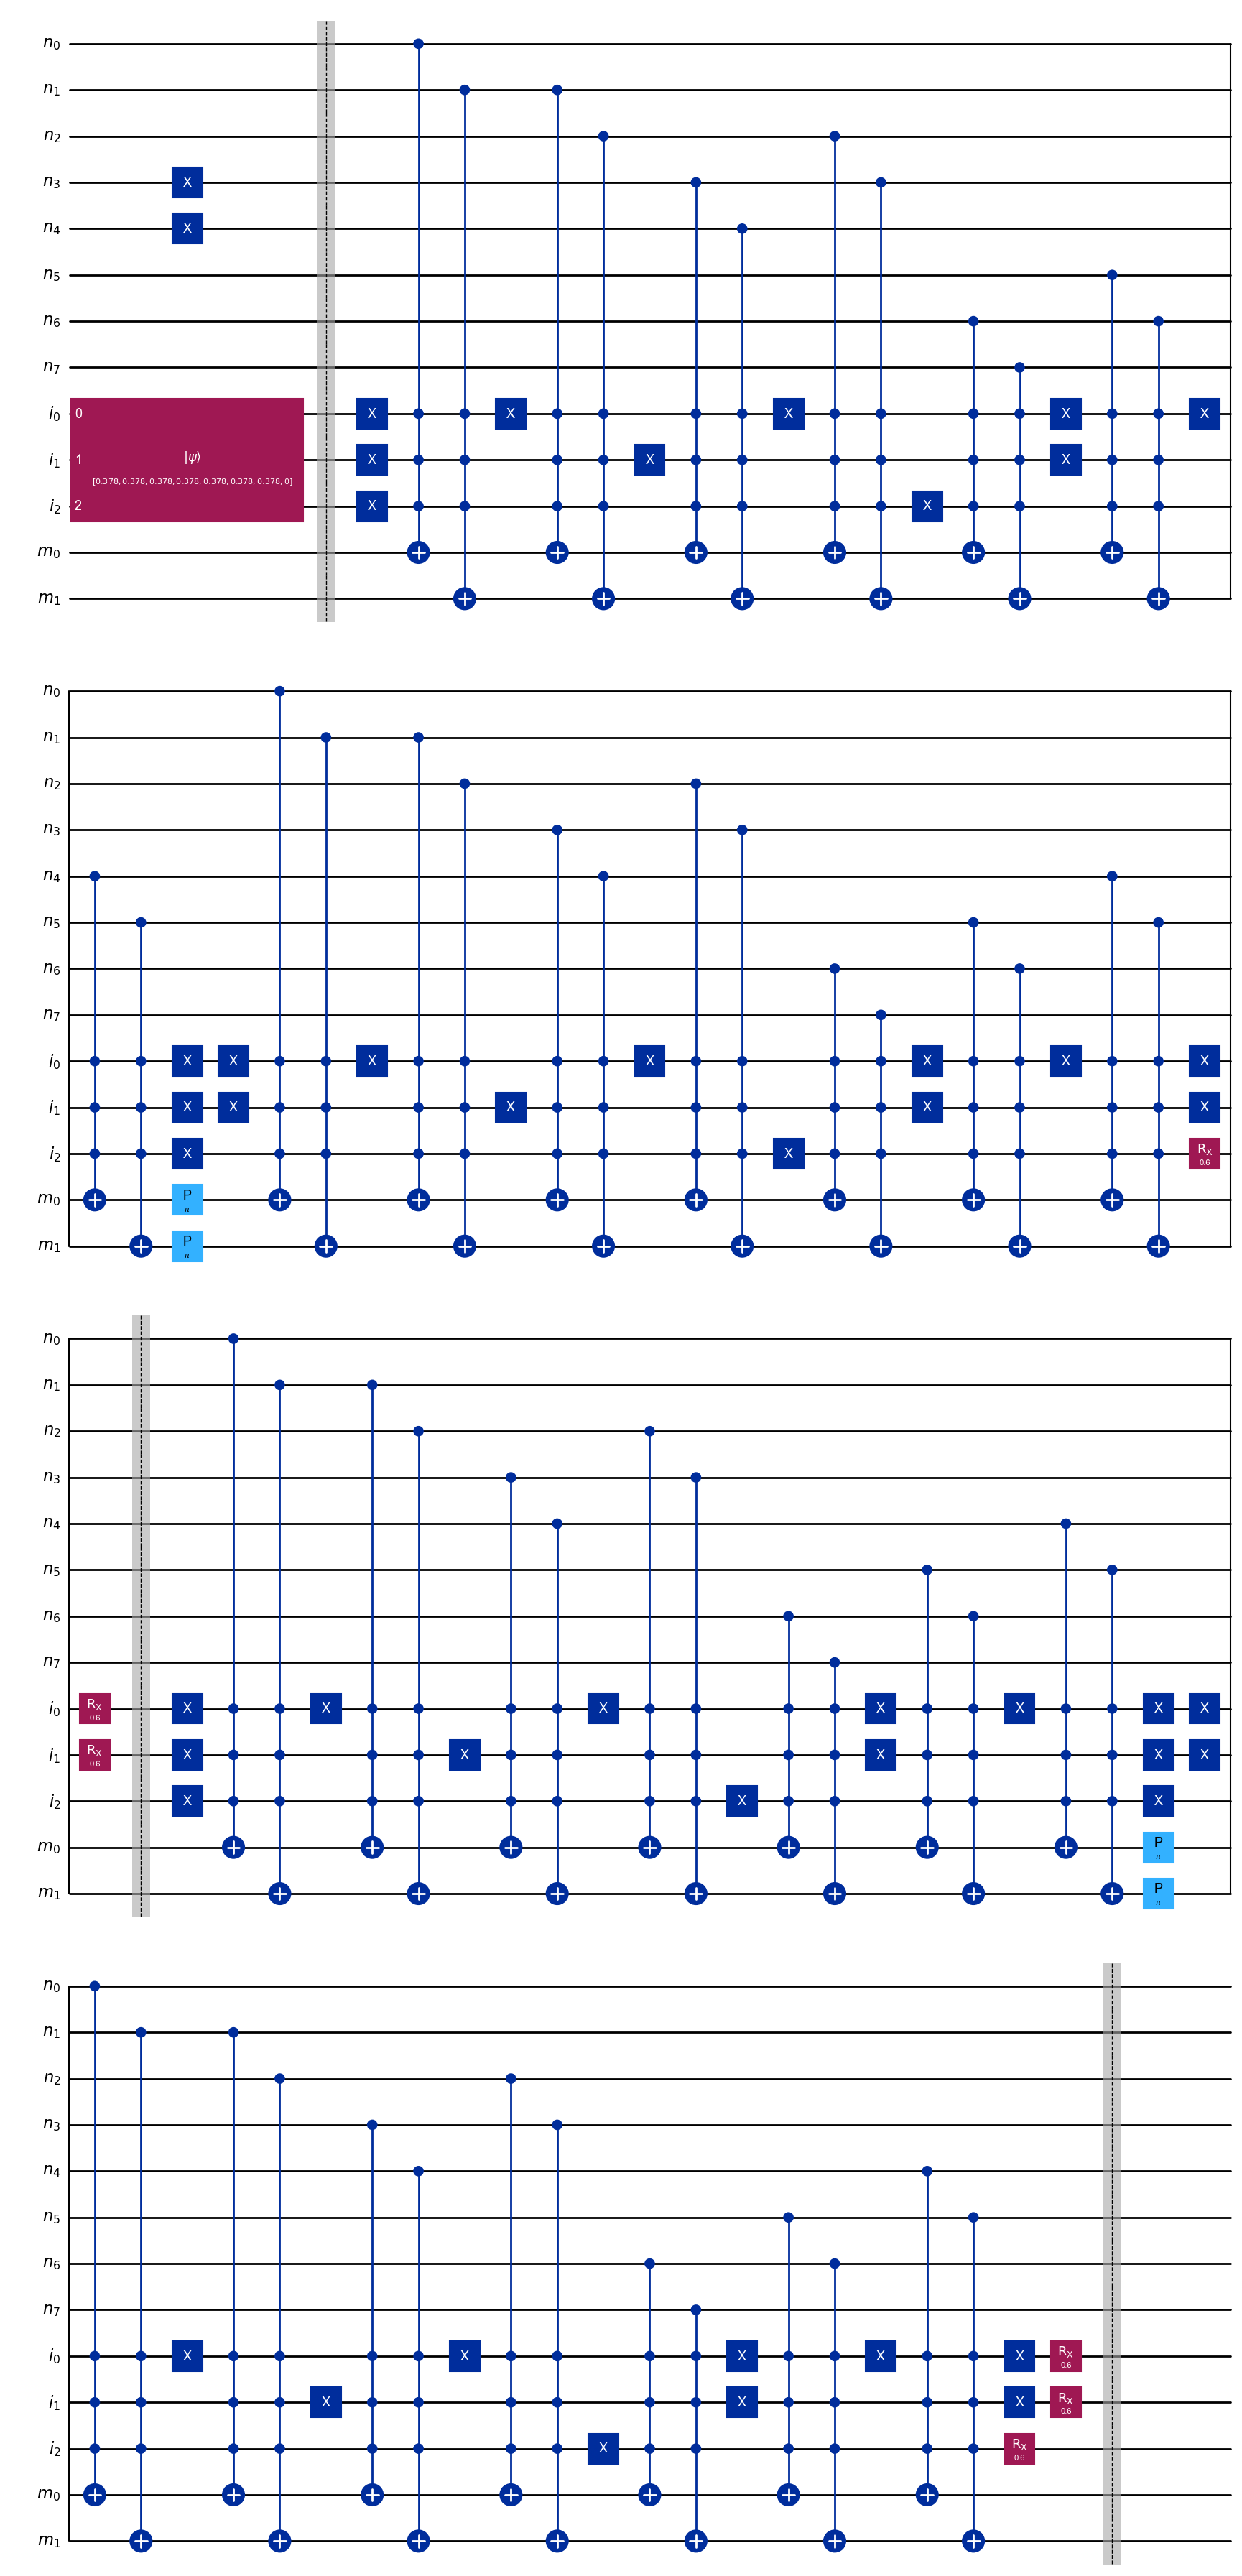



########################################
Experiment: Compact 2D test: 3x3 with 2x2 window
########################################

============ Compact 2D test: 3x3 with 2x2 window ============
N=[3, 3], M=[2, 2], W=4, IDX=2
theta=1.5708, mixer_angle=0.28, repetitions=2
mixer_method=rx_all
valid_indices=[2]
P_valid_initial = 0.250000
P_invalid_initial = 0.750000
P_valid_after   = 0.615132
P_invalid_after = 0.384868

index | start coordinate | window | C(i) | probability | valid
------|------------------|--------|------|-------------|------
    0 | (0, 0)           | 1000   |    1 |    0.040237 | False
    1 | (0, 1)           | 0100   |    1 |    0.304393 | False
    2 | (1, 0)           | 0000   |    0 |    0.615132 | True
    3 | (1, 1)           | 0001   |    1 |    0.040237 | False


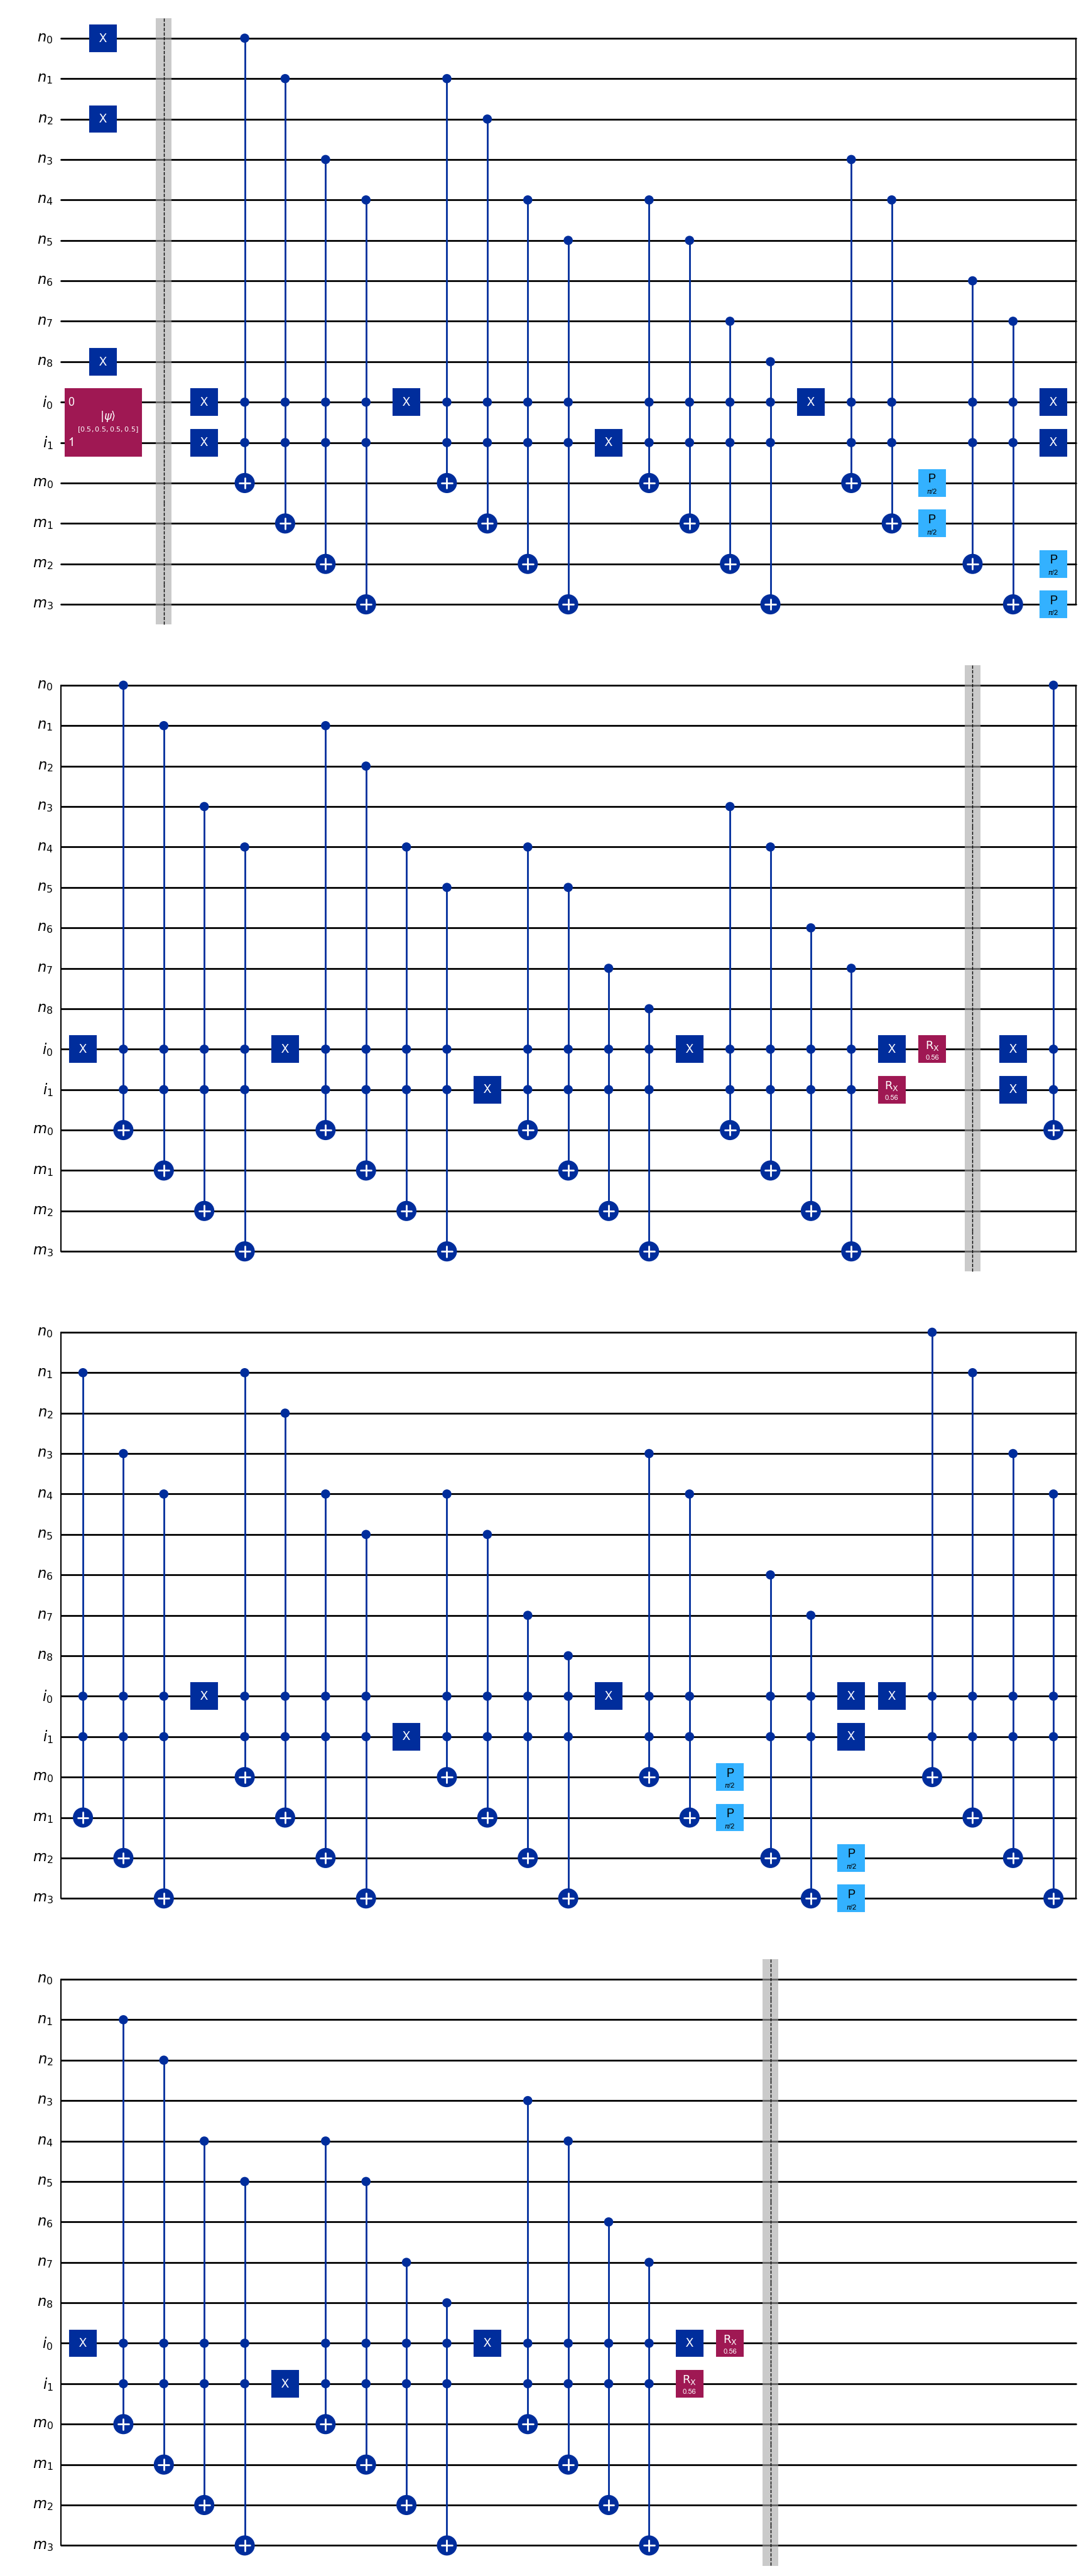

In [12]:
qc_test_1d, meta_test_1d, analysis_test_1d = run_experiment(
    name="Test 1D: consecutive occupied block",
    N=[8],
    M=[2],
    occupied_coords=[(3,), (4,)],
    theta=np.pi,
    mixer_angle=0.30,
    repetitions=2,
    mixer_method=mixer_method,
    draw=True
)

qc_test_2d, meta_test_2d, analysis_test_2d = run_experiment(
    name="Compact 2D test: 3x3 with 2x2 window",
    N=[3, 3],
    M=[2, 2],
    occupied_coords=[(0, 0), (0, 2), (2, 2)],
    theta=np.pi / 2,
    mixer_angle=0.28,
    repetitions=2,
    mixer_method=mixer_method,
    draw=True
)


## Design notes

- The cost phase is implemented as `P(theta)` on each qubit of the register `m` after loading `window_i`. This implements `exp(i theta C(i))` because each occupied cell contributes one phase `theta`.
- The same loader is then applied again to uncompute `m`, leaving the accumulated phase on `idx`.
- The default mixer is local on the graph of valid windows. It does not use Grover's global diffusion operator.
- `rx_all` remains as a simple prototype, but it can transfer amplitude to invalid indices when `W` is not a power of two.
- For large instances, the local mixer based on `UnitaryGate` should be replaced by a more efficient decomposition into native gates or by specialized geometric mixers.

## Case-study analysis

The main experiment above is intentionally kept as a manual sandbox: change `N`, `M`, `occupied_coords`, `theta`, `mixer_angle`, `repetitions`, and the mixer there when you want to run quick tests.

This section defines a shared ordered suite of 10 case studies, from very small 1D instances to larger 1D, 2D, and small 3D instances. For every case it applies the same analysis pipeline: repetition oscillation, two-parameter heatmap, spectrum/eigenvalue period study, theta scan, and a final dashboard with the optimal probabilities. The numerical sweeps use the exact `W`-dimensional index-space layer model, which is equivalent to the phase-plus-local-mixer dynamics and avoids repeatedly simulating auxiliary registers.


In [8]:
# =========================================================
# Case-study analysis for TFG V4
# =========================================================
# This block supersedes the previous single-instance Analysis 1-6 cells.
# The main experiment remains above for quick manual tests; the study cases
# below are the reproducible benchmark set for thesis figures.

import csv
import re
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

VALID_COLOR = "#2ecc71"
INVALID_COLOR = "#e74c3c"
BASELINE_COLOR = "0.45"
V4_OUTPUT_DIR = Path("analysis_v4_cases")
V4_OUTPUT_DIR.mkdir(exist_ok=True)

# Full analysis settings. Increase these for finer publication sweeps.
V4_CASE_MAX_REPS = 60
V4_GRID_POINTS = 31
V4_THETA_SCAN_POINTS = 121
V4_SPECTRAL_REPS = 80

V4_CASE_STUDIES = [
    {
        "name": "01_1d_tiny_single_gap",
        "description": "Minimal 1D case with one valid window.",
        "N": [6], "M": [2],
        "occupied_coords": [(0,), (3,), (4,)],
        "theta": np.pi / 2, "beta": 0.30, "mixer_method": "local_geometric",
    },
    {
        "name": "02_1d_main_reference",
        "description": "Reference 1D instance used in the manual main experiment.",
        "N": [8], "M": [2],
        "occupied_coords": [(0,), (1,), (2,), (6,), (7,)],
        "theta": np.pi / 3, "beta": 0.60, "mixer_method": "linear_valid",
    },
    {
        "name": "03_1d_two_free_regions",
        "description": "1D grid with two occupied blocks and a central valid plateau.",
        "N": [10], "M": [3],
        "occupied_coords": [(0,), (1,), (7,), (8,), (9,)],
        "theta": np.pi / 3, "beta": 0.30, "mixer_method": "linear_valid",
    },
    {
        "name": "04_1d_clustered_medium",
        "description": "Medium 1D case with several clustered obstacles.",
        "N": [16], "M": [3],
        "occupied_coords": [(0,), (1,), (5,), (6,), (7,), (13,), (14,)],
        "theta": np.pi / 3, "beta": 0.24, "mixer_method": "local_geometric",
    },
    {
        "name": "05_1d_long_clustered_blocks",
        "description": "Longer 1D case with separated occupied blocks.",
        "N": [32], "M": [4],
        "occupied_coords": [(0,), (1,), (2,), (9,), (10,), (11,), (18,), (19,), (28,), (29,), (30,), (31,)],
        "theta": np.pi / 4, "beta": 0.18, "mixer_method": "local_geometric",
    },
    {
        "name": "06_2d_tiny_corner_block",
        "description": "Small 2D case with a single valid 2x2 region.",
        "N": [3, 3], "M": [2, 2],
        "occupied_coords": [(0, 0), (0, 2), (2, 2)],
        "theta": np.pi / 2, "beta": 0.28, "mixer_method": "local_geometric",
    },
    {
        "name": "07_2d_small_diagonal_block",
        "description": "4x4 grid with diagonal obstacles and one clear lower-left solution.",
        "N": [4, 4], "M": [2, 2],
        "occupied_coords": [(1, 1), (2, 2), (0, 3)],
        "theta": np.pi / 2, "beta": 0.24, "mixer_method": "local_geometric",
    },
    {
        "name": "08_2d_medium_clustered_obstacles",
        "description": "5x5 grid with two compact occupied clusters.",
        "N": [5, 5], "M": [2, 2],
        "occupied_coords": [(0, 0), (0, 1), (1, 0), (3, 3), (3, 4), (4, 3)],
        "theta": np.pi / 3, "beta": 0.22, "mixer_method": "local_geometric",
    },
    {
        "name": "09_2d_rectangular_window",
        "description": "6x6 grid with a non-square 3x2 window.",
        "N": [6, 6], "M": [3, 2],
        "occupied_coords": [(0, 0), (0, 1), (1, 0), (4, 4), (4, 5), (5, 4), (2, 3)],
        "theta": np.pi / 3, "beta": 0.18, "mixer_method": "local_geometric",
    },
    {
        "name": "10_3d_small_clustered_obstacles",
        "description": "Small 3D grid with two compact occupied clusters.",
        "N": [4, 4, 3], "M": [2, 2, 2],
        "occupied_coords": [(0, 0, 0), (0, 0, 1), (1, 0, 0), (3, 3, 2), (3, 2, 2), (2, 3, 2)],
        "theta": np.pi / 4, "beta": 0.16, "mixer_method": "local_geometric",
    },
]


def v4_slug(text):
    return re.sub(r"[^a-zA-Z0-9_]+", "_", text).strip("_").lower()


def v4_savefig(fig, stem):
    pdf = V4_OUTPUT_DIR / f"{stem}.pdf"
    png = V4_OUTPUT_DIR / f"{stem}.png"
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, dpi=200, bbox_inches="tight")
    plt.close(fig)


def v4_case_context(case):
    N_case = list(case["N"])
    M_case = list(case["M"])
    occupied_case = list(case["occupied_coords"])
    validate_problem(N_case, M_case)
    starts_case = valid_starts_nd(N_case, M_case)
    grid_bits_case = build_grid_bits(N_case, occupied_case)
    costs_case = [compute_window_cost_classical(grid_bits_case, s, N_case, M_case) for s in starts_case]
    valid_indices_case = [i for i, c in enumerate(costs_case) if c == 0]
    if not valid_indices_case:
        raise ValueError(f"Case {case['name']} has no valid windows; change occupied_coords.")
    W_case = len(starts_case)
    return {
        "name": case["name"],
        "description": case.get("description", ""),
        "N": N_case,
        "M": M_case,
        "occupied_coords": occupied_case,
        "starts": starts_case,
        "grid_bits": grid_bits_case,
        "costs": costs_case,
        "valid_indices": valid_indices_case,
        "W": W_case,
        "P_uniform": len(valid_indices_case) / W_case,
        "theta_default": float(case.get("theta", globals().get("theta", np.pi / 3))),
        "beta_default": float(case.get("beta", globals().get("mixer_angle", 0.25))),
        "mixer_method": case.get("mixer_method", "local_geometric"),
    }


def v4_two_level_matrix(W, a, b, beta):
    U = np.eye(W, dtype=complex)
    c = np.cos(beta)
    s = -1j * np.sin(beta)
    U[a, a] = c
    U[b, b] = c
    U[a, b] = s
    U[b, a] = s
    return U


def v4_phase_vector(ctx, theta_value):
    return theta_value * np.asarray(ctx["costs"], dtype=float)


def v4_layer_matrix(ctx, theta_value, beta_value):
    W_case = ctx["W"]
    D = np.diag(np.exp(1j * v4_phase_vector(ctx, theta_value)))
    U_mix = np.eye(W_case, dtype=complex)
    edges = mixer_edges_from_starts(ctx["starts"], ctx["N"], ctx["mixer_method"])
    for a, b in edges:
        U_mix = v4_two_level_matrix(W_case, a, b, beta_value) @ U_mix
    return U_mix @ D


def v4_initial_state(ctx):
    return np.ones(ctx["W"], dtype=complex) / np.sqrt(ctx["W"])


def v4_probabilities(ctx, theta_value, beta_value, reps_value):
    U = v4_layer_matrix(ctx, theta_value, beta_value)
    psi = v4_initial_state(ctx)
    for _ in range(int(reps_value)):
        psi = U @ psi
    return np.abs(psi) ** 2


def v4_p_valid(ctx, probs):
    return float(np.sum(np.asarray(probs)[ctx["valid_indices"]]))


def v4_oscillation_curve(ctx, theta_value, beta_value, max_reps=V4_CASE_MAX_REPS):
    U = v4_layer_matrix(ctx, theta_value, beta_value)
    psi = v4_initial_state(ctx)
    reps = np.arange(1, max_reps + 1)
    values = []
    for _r in reps:
        psi = U @ psi
        values.append(v4_p_valid(ctx, np.abs(psi) ** 2))
    return reps, np.asarray(values, dtype=float)


def v4_heatmap(ctx, r_star):
    theta_values = np.linspace(0.0, np.pi, V4_GRID_POINTS)
    beta_values = np.linspace(0.0, np.pi / 2, V4_GRID_POINTS)
    grid = np.zeros((len(theta_values), len(beta_values)))
    for i, theta_value in enumerate(theta_values):
        for j, beta_value in enumerate(beta_values):
            grid[i, j] = v4_p_valid(ctx, v4_probabilities(ctx, theta_value, beta_value, r_star))
    return theta_values, beta_values, grid


def v4_theta_scan(ctx, beta_value, r_star):
    theta_values = np.linspace(0.0, 2 * np.pi, V4_THETA_SCAN_POINTS)
    values = np.asarray([v4_p_valid(ctx, v4_probabilities(ctx, t, beta_value, r_star)) for t in theta_values])
    return theta_values, values


def v4_spectral_curve(ctx, theta_value, beta_value, max_reps=V4_SPECTRAL_REPS):
    U = v4_layer_matrix(ctx, theta_value, beta_value)
    eigvals, eigvecs = np.linalg.eig(U)
    coeff = np.linalg.solve(eigvecs, v4_initial_state(ctx))
    reps = np.arange(1, max_reps + 1)
    direct = []
    spectral = []
    psi = v4_initial_state(ctx)
    for r in reps:
        psi = U @ psi
        direct.append(v4_p_valid(ctx, np.abs(psi) ** 2))
        psi_spec = eigvecs @ ((eigvals ** r) * coeff)
        spectral.append(v4_p_valid(ctx, np.abs(psi_spec) ** 2))
    return eigvals, reps, np.asarray(direct), np.asarray(spectral)


def v4_plot_case(ctx):
    prefix = f"v4_{v4_slug(ctx['name'])}"
    theta_default = ctx["theta_default"]
    beta_default = ctx["beta_default"]

    reps, p_curve = v4_oscillation_curve(ctx, theta_default, beta_default)
    r_star = int(reps[int(np.argmax(p_curve))])
    p_star_default = float(np.max(p_curve))

    theta_grid, beta_grid, heat = v4_heatmap(ctx, r_star)
    best_i, best_j = np.unravel_index(int(np.argmax(heat)), heat.shape)
    theta_opt = float(theta_grid[best_i])
    beta_opt = float(beta_grid[best_j])
    p_opt = float(heat[best_i, best_j])

    theta_scan_values, theta_scan_probs = v4_theta_scan(ctx, beta_default, r_star)
    theta_scan_idx = int(np.argmax(theta_scan_probs))
    theta_scan_opt = float(theta_scan_values[theta_scan_idx])
    p_theta_scan_opt = float(theta_scan_probs[theta_scan_idx])

    eigvals, spectral_reps, direct_curve, spectral_curve = v4_spectral_curve(ctx, theta_default, beta_default)
    opt_probs = v4_probabilities(ctx, theta_opt, beta_opt, r_star)

    # Analysis 1: oscillation curve.
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(reps, p_curve, marker="o", linewidth=2, color=VALID_COLOR, label="P_valid")
    ax.axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    ax.axvline(r_star, color="black", linestyle=":", linewidth=1.5, label=f"r*={r_star}")
    ax.annotate(f"max={p_star_default:.3f}", xy=(r_star, p_star_default), xytext=(r_star + 1, min(1.0, p_star_default + 0.08)), arrowprops={"arrowstyle": "->", "lw": 1.0})
    ax.set_xlabel("repetitions r")
    ax.set_ylabel("P_valid")
    ax.set_title(f"V4 oscillation - {ctx['name']}")
    ax.legend()
    fig.tight_layout()
    v4_savefig(fig, f"{prefix}_01_oscillation")

    # Analysis 2: heatmap.
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(heat, origin="lower", aspect="auto", cmap="viridis", extent=[beta_grid[0] / np.pi, beta_grid[-1] / np.pi, theta_grid[0] / np.pi, theta_grid[-1] / np.pi])
    ax.scatter([beta_opt / np.pi], [theta_opt / np.pi], marker="*", s=180, color="white", edgecolor="black", linewidth=0.7, label="optimum")
    ax.set_xlabel("beta / pi")
    ax.set_ylabel("theta / pi")
    ax.set_title(f"V4 P_valid heatmap at r={r_star} - {ctx['name']}")
    ax.legend(loc="lower right")
    fig.colorbar(im, ax=ax, label="P_valid")
    fig.tight_layout()
    v4_savefig(fig, f"{prefix}_02_heatmap")

    # Analysis 3: eigenvalue spectrum and period prediction.
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    unit = np.exp(1j * np.linspace(0, 2 * np.pi, 400))
    axes[0].plot(unit.real, unit.imag, color="0.75", linewidth=1.2)
    sc = axes[0].scatter(eigvals.real, eigvals.imag, c=eigvals.imag, cmap="viridis", s=45)
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].set_xlabel("Re(lambda)")
    axes[0].set_ylabel("Im(lambda)")
    axes[0].set_title("One-layer spectrum")
    fig.colorbar(sc, ax=axes[0], label="Im(lambda)")
    axes[1].plot(spectral_reps, direct_curve, color=VALID_COLOR, linewidth=2, label="direct layer chain")
    axes[1].plot(spectral_reps, spectral_curve, color="black", linestyle="--", linewidth=1.4, label="eigen reconstruction")
    axes[1].axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    axes[1].set_xlabel("repetitions r")
    axes[1].set_ylabel("P_valid")
    axes[1].set_title("Period prediction")
    axes[1].legend()
    fig.suptitle(f"V4 eigenvalue analysis - {ctx['name']}", fontsize=15)
    fig.tight_layout()
    v4_savefig(fig, f"{prefix}_03_spectrum")

    # Analysis 4: theta scan.
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(theta_scan_values / np.pi, theta_scan_probs, color=VALID_COLOR, linewidth=2, label="P_valid")
    ax.axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    ax.axvline(theta_scan_opt / np.pi, color="black", linestyle=":", linewidth=1.5, label=f"theta*={theta_scan_opt / np.pi:.3f} pi")
    ax.set_xlabel("theta / pi")
    ax.set_ylabel("P_valid")
    ax.set_title(f"V4 theta scan at beta={beta_default:.3f}, r={r_star} - {ctx['name']}")
    ax.legend()
    fig.tight_layout()
    v4_savefig(fig, f"{prefix}_04_theta_scan")

    # Analysis 5: summary dashboard.
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes[0, 0].plot(reps, p_curve, marker="o", linewidth=2, color=VALID_COLOR, label="P_valid")
    axes[0, 0].axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    axes[0, 0].axvline(r_star, color="black", linestyle=":", linewidth=1.2)
    axes[0, 0].set_xlabel("repetitions r")
    axes[0, 0].set_ylabel("P_valid")
    axes[0, 0].set_title("Oscillation")
    axes[0, 0].legend()
    im = axes[0, 1].imshow(heat, origin="lower", aspect="auto", cmap="viridis", extent=[beta_grid[0] / np.pi, beta_grid[-1] / np.pi, theta_grid[0] / np.pi, theta_grid[-1] / np.pi])
    axes[0, 1].scatter([beta_opt / np.pi], [theta_opt / np.pi], marker="*", s=180, color="white", edgecolor="black", linewidth=0.7)
    axes[0, 1].set_xlabel("beta / pi")
    axes[0, 1].set_ylabel("theta / pi")
    axes[0, 1].set_title("Heatmap")
    fig.colorbar(im, ax=axes[0, 1], label="P_valid")
    axes[1, 0].plot(theta_scan_values / np.pi, theta_scan_probs, color=VALID_COLOR, linewidth=2)
    axes[1, 0].axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5)
    axes[1, 0].axvline(theta_scan_opt / np.pi, color="black", linestyle=":", linewidth=1.2)
    axes[1, 0].set_xlabel("theta / pi")
    axes[1, 0].set_ylabel("P_valid")
    axes[1, 0].set_title("Theta scan")
    bar_colors = [VALID_COLOR if i in ctx["valid_indices"] else INVALID_COLOR for i in range(ctx["W"])]
    axes[1, 1].bar(np.arange(ctx["W"]), opt_probs, color=bar_colors)
    axes[1, 1].axhline(1 / ctx["W"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform 1/W")
    axes[1, 1].set_xlabel("window index")
    axes[1, 1].set_ylabel("probability")
    axes[1, 1].set_title("Optimal distribution")
    axes[1, 1].legend()
    fig.suptitle(f"V4 case summary - {ctx['name']}", fontsize=16)
    fig.tight_layout(rect=[0, 0.02, 1, 0.96])
    v4_savefig(fig, f"{prefix}_05_summary")

    return {
        "version": "V4",
        "case": ctx["name"],
        "description": ctx["description"],
        "N": str(ctx["N"]),
        "M": str(ctx["M"]),
        "W": ctx["W"],
        "valid_windows": len(ctx["valid_indices"]),
        "P_uniform": ctx["P_uniform"],
        "theta_default": theta_default,
        "beta_default": beta_default,
        "r_star_default": r_star,
        "P_star_default": p_star_default,
        "theta_opt_heatmap": theta_opt,
        "beta_opt_heatmap": beta_opt,
        "P_opt_heatmap": p_opt,
        "theta_opt_scan_default_beta": theta_scan_opt,
        "P_opt_scan_default_beta": p_theta_scan_opt,
        "mixer_method": ctx["mixer_method"],
    }


def v4_run_all_case_studies():
    rows = []
    start = time.time()
    for case in V4_CASE_STUDIES:
        try:
            ctx = v4_case_context(case)
            print(f"[V4] Case {ctx['name']}: N={ctx['N']}, M={ctx['M']}, W={ctx['W']}, valid={len(ctx['valid_indices'])}, uniform={ctx['P_uniform']:.4f}")
            row = v4_plot_case(ctx)
            rows.append(row)
            print(f"      best heatmap: P_valid={row['P_opt_heatmap']:.6f}, theta={row['theta_opt_heatmap']:.6f}, beta={row['beta_opt_heatmap']:.6f}, r={row['r_star_default']}")
        except Exception as exc:
            print(f"[V4] Case skipped {case.get('name', '<unknown>')}: {exc}")

    if not rows:
        print("[V4] No case studies completed.")
        return []

    csv_name = V4_OUTPUT_DIR / "v4_case_study_summary.csv"
    with open(csv_name, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    labels = [row["case"].replace("_", "\n", 2) for row in rows]
    x = np.arange(len(rows))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - 0.18, [row["P_uniform"] for row in rows], width=0.36, color="0.7", label="uniform K/W")
    ax.bar(x + 0.18, [row["P_opt_heatmap"] for row in rows], width=0.36, color=VALID_COLOR, label="best scanned P_valid")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("P_valid")
    ax.set_title("V4 default-mixer case-study heatmap overview")
    ax.legend()
    fig.tight_layout()
    v4_savefig(fig, "v4_default_mixer_case_study_overview")

    print(f"[V4] Completed {len(rows)} case studies in {time.time() - start:.1f}s")
    print(f"[V4] Summary CSV and figures saved in: {V4_OUTPUT_DIR}")
    return rows


v4_case_study_results = v4_run_all_case_studies()


# =========================================================
# ANALYSIS 6 — Parameter optimization methods across all case studies
# =========================================================
import csv
import time
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

FAST_MODE = False  # set True to reduce sweep for large N

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

VALID_COLOR = "#2ecc71"
BASELINE_COLOR = "0.45"
PARAM_OUTPUT_DIR = Path("analysis_v4_cases")
PARAM_OUTPUT_DIR.mkdir(exist_ok=True)

M1_THETA_POINTS = 10 if FAST_MODE else 25
M1_BETA_POINTS = 10 if FAST_MODE else 25
M1_R_MAX = 15 if FAST_MODE else 29
M2_R_MAX = 60
M4_MAX_ITERS = 100 if FAST_MODE else 200
HYBRID_REFINE_POINTS = 5 if FAST_MODE else 9
MIXER_METHODS_V4 = ["local_geometric", "linear_valid", "rx_all"]


def v4_opt_context(case, mixer_method=None):
    N_case = list(case["N"])
    M_case = list(case["M"])
    occupied_case = list(case["occupied_coords"])
    validate_problem(N_case, M_case)
    starts_case = valid_starts_nd(N_case, M_case)
    grid_bits_case = build_grid_bits(N_case, occupied_case)
    costs_case = [compute_window_cost_classical(grid_bits_case, s, N_case, M_case) for s in starts_case]
    valid_indices_case = [i for i, c in enumerate(costs_case) if c == 0]
    if not valid_indices_case:
        raise ValueError(f"Case {case['name']} has no valid windows.")
    W_case = len(starts_case)
    IDX_case = int(np.ceil(np.log2(W_case))) if W_case > 1 else 1
    DIM_case = 2 ** IDX_case
    mixer_case = mixer_method or case.get("mixer_method", "local_geometric")
    return {
        "name": case["name"],
        "description": case.get("description", ""),
        "N": N_case,
        "M": M_case,
        "starts": starts_case,
        "grid_bits": grid_bits_case,
        "costs": costs_case,
        "valid_indices": valid_indices_case,
        "W": W_case,
        "IDX": IDX_case,
        "DIM": DIM_case,
        "theta_default": float(case.get("theta", globals().get("theta", np.pi / 3))),
        "beta_default": float(case.get("beta", globals().get("mixer_angle", 0.25))),
        "mixer_method": mixer_case,
        "P_uniform": len(valid_indices_case) / W_case,
    }


def v4_opt_gate_matrix(ctx, a, b, beta_value):
    return np.asarray(two_level_mixer_gate(ctx["IDX"], a, b, beta_value).to_matrix(), dtype=complex)


def v4_opt_phase(ctx, theta_value):
    phases = np.zeros(ctx["DIM"], dtype=float)
    phases[:ctx["W"]] = theta_value * np.asarray(ctx["costs"], dtype=float)
    return phases


def v4_opt_rx_all_matrix(ctx, beta_value):
    c = np.cos(beta_value)
    s = -1j * np.sin(beta_value)
    rx = np.asarray([[c, s], [s, c]], dtype=complex)
    U = np.asarray([[1.0 + 0.0j]], dtype=complex)
    for _ in range(ctx["IDX"]):
        U = np.kron(U, rx)
    return U


def v4_mixer_edges_for_analysis(ctx):
    if ctx["mixer_method"] == "rx_all":
        return [(a, b) for a in range(ctx["W"]) for b in range(a + 1, ctx["W"]) if bin(a ^ b).count("1") == 1]
    return mixer_edges_from_starts(ctx["starts"], ctx["N"], ctx["mixer_method"])


def v4_opt_mixer(ctx, beta_value):
    if ctx["mixer_method"] == "rx_all":
        return v4_opt_rx_all_matrix(ctx, beta_value)
    U_mix = np.eye(ctx["DIM"], dtype=complex)
    for a, b in v4_mixer_edges_for_analysis(ctx):
        U_mix = v4_opt_gate_matrix(ctx, a, b, beta_value) @ U_mix
    return U_mix


def v4_opt_layer(ctx, theta_value, beta_value):
    D = np.diag(np.exp(1j * v4_opt_phase(ctx, theta_value)))
    return v4_opt_mixer(ctx, beta_value) @ D


def v4_opt_initial(ctx):
    psi = np.zeros(ctx["DIM"], dtype=complex)
    psi[:ctx["W"]] = 1.0 / np.sqrt(ctx["W"])
    return psi


def v4_opt_p_from_state(ctx, psi):
    return float(np.sum(np.abs(psi[ctx["valid_indices"]]) ** 2))


def v4_opt_p_valid(ctx, theta_value, beta_value, r_value):
    U = v4_opt_layer(ctx, theta_value, beta_value)
    psi = v4_opt_initial(ctx)
    for _ in range(int(r_value)):
        psi = U @ psi
    return v4_opt_p_from_state(ctx, psi)


def v4_opt_curve(ctx, theta_value, beta_value, r_max=M2_R_MAX):
    U = v4_opt_layer(ctx, theta_value, beta_value)
    psi = v4_opt_initial(ctx)
    reps = np.arange(1, r_max + 1)
    values = []
    for _ in reps:
        psi = U @ psi
        values.append(v4_opt_p_from_state(ctx, psi))
    return reps, np.asarray(values, dtype=float)


def v4_existing_experimental(ctx):
    for row in globals().get("v4_case_study_results", []):
        if row.get("case") == ctx["name"] and row.get("mixer_method") == ctx["mixer_method"]:
            return {
                "method": "Experimental",
                "theta": float(row["theta_opt_heatmap"]),
                "beta": float(row["beta_opt_heatmap"]),
                "r": int(row["r_star_default"]),
                "P": float(row["P_opt_heatmap"]),
            }
    return None


def v4_method1(ctx):
    theta_values = np.linspace(0.0, np.pi, M1_THETA_POINTS)
    beta_values = np.linspace(0.0, np.pi / 2, M1_BETA_POINTS)
    best = {"method": "M1 (sweep)", "theta": np.nan, "beta": np.nan, "r": np.nan, "P": -np.inf}
    t0 = time.perf_counter()
    for ti, theta_value in enumerate(theta_values):
        if ti % 5 == 0:
            print(f"[V4 M1] {ctx['name']}: theta point {ti + 1}/{len(theta_values)}")
        D = np.diag(np.exp(1j * v4_opt_phase(ctx, theta_value)))
        for beta_value in beta_values:
            U = v4_opt_mixer(ctx, beta_value) @ D
            psi = v4_opt_initial(ctx)
            for r_value in range(1, M1_R_MAX + 1):
                psi = U @ psi
                p_value = v4_opt_p_from_state(ctx, psi)
                if p_value > best["P"]:
                    best = {"method": "M1 (sweep)", "theta": float(theta_value), "beta": float(beta_value), "r": int(r_value), "P": float(p_value)}
    print(f"[V4 M1] {ctx['name']} completed in {time.perf_counter() - t0:.2f}s")
    return best


def v4_method2(ctx):
    U = v4_opt_layer(ctx, ctx["theta_default"], ctx["beta_default"])
    eigenvalues, V = np.linalg.eig(U)
    try:
        coeffs = np.linalg.solve(V, v4_opt_initial(ctx))
    except np.linalg.LinAlgError:
        coeffs = np.linalg.pinv(V) @ v4_opt_initial(ctx)
    reps = np.arange(1, M2_R_MAX + 1)
    analytical = []
    direct = []
    psi_direct = v4_opt_initial(ctx)
    for r_value in reps:
        psi_direct = U @ psi_direct
        direct.append(v4_opt_p_from_state(ctx, psi_direct))
        psi_eig = V @ ((eigenvalues ** r_value) * coeffs)
        analytical.append(v4_opt_p_from_state(ctx, psi_eig))
    analytical = np.asarray(analytical, dtype=float)
    direct = np.asarray(direct, dtype=float)
    deviation = float(np.max(np.abs(analytical - direct)))
    idx = int(np.argmax(analytical))
    return {
        "method": "M2 (eigen)",
        "theta": ctx["theta_default"],
        "beta": ctx["beta_default"],
        "r": int(reps[idx]),
        "P": float(analytical[idx]),
        "eig_deviation": deviation,
    }


def v4_method3(ctx):
    valid_set = set(ctx["valid_indices"])
    invalid_neighbor_costs = []
    invalid_counts = []
    for a in ctx["valid_indices"]:
        count = 0
        for u, v in v4_mixer_edges_for_analysis(ctx):
            other = v if u == a else u if v == a else None
            if other is not None and other not in valid_set and ctx["costs"][other] > 0:
                invalid_neighbor_costs.append(ctx["costs"][other])
                count += 1
        invalid_counts.append(count)
    c_min = min(invalid_neighbor_costs) if invalid_neighbor_costs else 1
    n_avg = float(np.mean(invalid_counts)) if invalid_counts else 1.0
    theta_theory = np.pi / (2 * c_min)
    beta_theory = np.arctan(n_avg)
    return {"method": "M3 (theory)", "theta": float(theta_theory), "beta": float(beta_theory), "r": 1, "P": v4_opt_p_valid(ctx, theta_theory, beta_theory, 1)}


def v4_method4(ctx, r_fixed):
    theta_value = np.pi / 4
    beta_value = np.pi / 6
    history = []
    for _ in range(M4_MAX_ITERS):
        p_now = v4_opt_p_valid(ctx, theta_value, beta_value, r_fixed)
        history.append(p_now)
        g_theta = (v4_opt_p_valid(ctx, theta_value + np.pi / 2, beta_value, r_fixed) - v4_opt_p_valid(ctx, theta_value - np.pi / 2, beta_value, r_fixed)) / 2
        g_beta = (v4_opt_p_valid(ctx, theta_value, beta_value + np.pi / 2, r_fixed) - v4_opt_p_valid(ctx, theta_value, beta_value - np.pi / 2, r_fixed)) / 2
        if np.sqrt(g_theta ** 2 + g_beta ** 2) < 1e-4:
            break
        theta_value = (theta_value + 0.05 * g_theta) % (2 * np.pi)
        beta_value = abs(beta_value + 0.05 * g_beta) % np.pi
    p_final = v4_opt_p_valid(ctx, theta_value, beta_value, r_fixed)
    history.append(p_final)
    return {"method": "M4 (grad)", "theta": float(theta_value), "beta": float(beta_value), "r": int(r_fixed), "P": float(p_final), "grad_iters": len(history)}


def v4_best_r_for_layer(ctx, U, r_max=M2_R_MAX):
    psi = v4_opt_initial(ctx)
    best_r = 1
    best_p = -np.inf
    for r_value in range(1, int(r_max) + 1):
        psi = U @ psi
        p_value = v4_opt_p_from_state(ctx, psi)
        if p_value > best_p:
            best_r = int(r_value)
            best_p = float(p_value)
    return best_r, best_p


def v4_method5(ctx):
    theta_values = np.linspace(0.0, np.pi, M1_THETA_POINTS)
    beta_values = np.linspace(0.0, np.pi / 2, M1_BETA_POINTS)
    best = {"method": "M5 (hybrid)", "theta": np.nan, "beta": np.nan, "r": np.nan, "P": -np.inf}
    t0 = time.perf_counter()

    def evaluate(theta_value, beta_value):
        U = v4_opt_layer(ctx, theta_value, beta_value)
        r_value, p_value = v4_best_r_for_layer(ctx, U, M2_R_MAX)
        return {"method": "M5 (hybrid)", "theta": float(theta_value), "beta": float(beta_value), "r": int(r_value), "P": float(p_value)}

    seeds = [(ctx["theta_default"], ctx["beta_default"])]
    try:
        theory = v4_method3(ctx)
        seeds.append((theory["theta"], theory["beta"]))
    except Exception:
        pass

    for ti, theta_value in enumerate(theta_values):
        if ti % 5 == 0:
            print(f"[V4 M5] {ctx['name']}: theta point {ti + 1}/{len(theta_values)}")
        for beta_value in beta_values:
            candidate = evaluate(theta_value, beta_value)
            if candidate["P"] > best["P"]:
                best = candidate
    for theta_value, beta_value in seeds:
        candidate = evaluate(theta_value, beta_value)
        if candidate["P"] > best["P"]:
            best = candidate

    theta_step = np.pi / max(1, M1_THETA_POINTS - 1)
    beta_step = (np.pi / 2) / max(1, M1_BETA_POINTS - 1)
    theta_refine = np.linspace(max(0.0, best["theta"] - theta_step), min(np.pi, best["theta"] + theta_step), HYBRID_REFINE_POINTS)
    beta_refine = np.linspace(max(0.0, best["beta"] - beta_step), min(np.pi / 2, best["beta"] + beta_step), HYBRID_REFINE_POINTS)
    for theta_value in theta_refine:
        for beta_value in beta_refine:
            candidate = evaluate(theta_value, beta_value)
            if candidate["P"] > best["P"]:
                best = candidate
    best["hybrid_seconds"] = time.perf_counter() - t0
    print(f"[V4 M5] {ctx['name']} completed in {best['hybrid_seconds']:.2f}s")
    return best


def v4_fallback_experimental(ctx):
    reps, curve = v4_opt_curve(ctx, ctx["theta_default"], ctx["beta_default"], M2_R_MAX)
    r_star = int(reps[int(np.argmax(curve))])
    theta_values = np.linspace(0.0, np.pi, M1_THETA_POINTS)
    beta_values = np.linspace(0.0, np.pi / 2, M1_BETA_POINTS)
    best = {"method": "Experimental", "theta": ctx["theta_default"], "beta": ctx["beta_default"], "r": r_star, "P": float(np.max(curve))}
    for theta_value in theta_values:
        for beta_value in beta_values:
            p_value = v4_opt_p_valid(ctx, theta_value, beta_value, r_star)
            if p_value > best["P"]:
                best = {"method": "Experimental", "theta": float(theta_value), "beta": float(beta_value), "r": r_star, "P": float(p_value)}
    return best


def v4_record(ctx, result, experimental):
    return {
        "case": ctx["name"],
        "transition_mode": "cost_phase",
        "mixer_method": ctx["mixer_method"],
        "method": result["method"],
        "theta": result["theta"],
        "theta_over_pi": result["theta"] / np.pi,
        "beta": result["beta"],
        "beta_over_pi": result["beta"] / np.pi,
        "r": result["r"],
        "P_valid": result["P"],
        "P_uniform": ctx["P_uniform"],
        "delta_theta_pi_vs_exp": (result["theta"] - experimental["theta"]) / np.pi,
        "delta_beta_pi_vs_exp": (result["beta"] - experimental["beta"]) / np.pi,
        "delta_r_vs_exp": int(result["r"] - experimental["r"]),
        "delta_P_vs_exp": result["P"] - experimental["P"],
        "W": ctx["W"],
        "valid_windows": len(ctx["valid_indices"]),
    }

all_rows_v4 = []
for case in V4_CASE_STUDIES:
    try:
        for mixer_method in MIXER_METHODS_V4:
            ctx = v4_opt_context(case, mixer_method=mixer_method)
            print(f"\n[V4 Analysis 6] Case {ctx['name']} | mixer={ctx['mixer_method']} | W={ctx['W']} | valid={len(ctx['valid_indices'])} | uniform={ctx['P_uniform']:.4f}")
            m1 = v4_method1(ctx)
            m2 = v4_method2(ctx)
            print(f"Eigenvalue method verified for {ctx['name']} / {ctx['mixer_method']}: max deviation = {m2.get('eig_deviation', np.nan):.3e}")
            m3 = v4_method3(ctx)
            m4 = v4_method4(ctx, int(m2["r"]))
            m5 = v4_method5(ctx)
            experimental = v4_existing_experimental(ctx) or v4_fallback_experimental(ctx)
            for result in [m1, m2, m3, m4, m5, experimental]:
                all_rows_v4.append(v4_record(ctx, result, experimental))
    except Exception as exc:
        print(f"WARNING: V4 Analysis 6 skipped case {case.get('name', '<unknown>')}: {exc}")

csv_path = PARAM_OUTPUT_DIR / "v4_param_methods_all_cases.csv"
if all_rows_v4:
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(all_rows_v4[0].keys()))
        writer.writeheader()
        writer.writerows(all_rows_v4)

    methods = ["M1 (sweep)", "M2 (eigen)", "M3 (theory)", "M4 (grad)", "M5 (hybrid)", "Experimental"]
    cases = [case["name"] for case in V4_CASE_STUDIES]
    summary_rows = []
    for case_name in cases:
        for method in methods:
            candidates = [row for row in all_rows_v4 if row["case"] == case_name and row["method"] == method]
            if candidates:
                summary_rows.append(max(candidates, key=lambda row: row["P_valid"]))
    x = np.arange(len(cases))
    width = 0.13
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for mi, method in enumerate(methods):
        method_rows = [next(row for row in summary_rows if row["case"] == case and row["method"] == method) for case in cases]
        offset = (mi - (len(methods) - 1) / 2) * width
        axes[0].bar(x + offset, [row["P_valid"] for row in method_rows], width=width, label=method)
        axes[1].bar(x + offset, [row["theta_over_pi"] for row in method_rows], width=width, label=method)
        axes[2].bar(x + offset, [row["beta_over_pi"] for row in method_rows], width=width, label=method)
    for ax, title, ylabel in zip(axes, ["P_valid by method", "theta/pi by method", "beta/pi by method"], ["P_valid", "theta/pi", "beta/pi"]):
        ax.set_xticks(x)
        ax.set_xticklabels([c.replace("_", "\n", 2) for c in cases], rotation=45, ha="right")
        ax.set_title(title)
        ax.set_ylabel(ylabel)
    axes[0].legend(fontsize=8)
    fig.suptitle("V4 parameter optimization methods across all case studies\n(best mixer per case/method; full table in CSV)", fontsize=15)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(PARAM_OUTPUT_DIR / "v4_param_methods_all_cases.pdf", bbox_inches="tight")
    fig.savefig(PARAM_OUTPUT_DIR / "v4_param_methods_all_cases.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    best_rows_v4 = []
    for case_name in cases:
        candidates = [row for row in all_rows_v4 if row["case"] == case_name]
        if candidates:
            best_rows_v4.append(max(candidates, key=lambda row: row["P_valid"]))

    best_csv = PARAM_OUTPUT_DIR / "v4_all_config_best_by_case.csv"
    with open(best_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(best_rows_v4[0].keys()))
        writer.writeheader()
        writer.writerows(best_rows_v4)

    combo_rows = []
    for mixer_method in MIXER_METHODS_V4:
        for method in methods:
            combo = [row for row in all_rows_v4 if row["mixer_method"] == mixer_method and row["method"] == method]
            if not combo:
                continue
            values = np.asarray([row["P_valid"] for row in combo], dtype=float)
            combo_rows.append({
                "transition_mode": "cost_phase",
                "mixer_method": mixer_method,
                "method": method,
                "mean_P_valid": float(np.mean(values)),
                "median_P_valid": float(np.median(values)),
                "std_P_valid": float(np.std(values)),
                "min_P_valid": float(np.min(values)),
                "max_P_valid": float(np.max(values)),
                "wins_best_by_case": int(sum(row["mixer_method"] == mixer_method and row["method"] == method for row in best_rows_v4)),
                "cases": len(combo),
            })
    combo_csv = PARAM_OUTPUT_DIR / "v4_all_config_summary_by_mixer_method.csv"
    with open(combo_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(combo_rows[0].keys()))
        writer.writeheader()
        writer.writerows(combo_rows)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - 0.18, [row["P_uniform"] for row in best_rows_v4], width=0.36, color="0.7", label="uniform K/W")
    ax.bar(x + 0.18, [row["P_valid"] for row in best_rows_v4], width=0.36, color=VALID_COLOR, label="best full sweep")
    for xi, row in zip(x, best_rows_v4):
        ax.text(xi + 0.18, min(1.04, row["P_valid"] + 0.025), f"{row['mixer_method']}\n{row['method']}", rotation=90, ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_", "\n", 2) for c in cases], rotation=45, ha="right")
    ax.set_ylabel("P_valid")
    ax.set_ylim(0, 1.12)
    ax.set_title("V4 full sweep best configuration by use case")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PARAM_OUTPUT_DIR / "v4_case_study_overview.pdf", bbox_inches="tight")
    fig.savefig(PARAM_OUTPUT_DIR / "v4_case_study_overview.png", dpi=200, bbox_inches="tight")
    fig.savefig(PARAM_OUTPUT_DIR / "v4_all_config_best_by_case.pdf", bbox_inches="tight")
    fig.savefig(PARAM_OUTPUT_DIR / "v4_all_config_best_by_case.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    heat = np.full((len(MIXER_METHODS_V4), len(methods)), np.nan)
    for i, mixer_method in enumerate(MIXER_METHODS_V4):
        for j, method in enumerate(methods):
            combo = [row["P_valid"] for row in all_rows_v4 if row["mixer_method"] == mixer_method and row["method"] == method]
            if combo:
                heat[i, j] = float(np.mean(combo))
    fig, ax = plt.subplots(figsize=(10, 4.5))
    im = ax.imshow(heat, cmap="viridis", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(methods)))
    ax.set_xticklabels(methods, rotation=25, ha="right")
    ax.set_yticks(np.arange(len(MIXER_METHODS_V4)))
    ax.set_yticklabels(MIXER_METHODS_V4)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, f"{heat[i, j]:.3f}", ha="center", va="center", color="white" if heat[i, j] < 0.65 else "black", fontsize=9)
    ax.set_title("V4 mean P_valid over all cases by mixer and optimization method")
    fig.colorbar(im, ax=ax, label="mean P_valid")
    fig.tight_layout()
    fig.savefig(PARAM_OUTPUT_DIR / "v4_all_config_mixer_method_heatmap.pdf", bbox_inches="tight")
    fig.savefig(PARAM_OUTPUT_DIR / "v4_all_config_mixer_method_heatmap.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    axes[0].bar(x, [row["theta_over_pi"] for row in best_rows_v4], color="#3498db")
    axes[1].bar(x, [row["beta_over_pi"] for row in best_rows_v4], color="#9b59b6")
    axes[2].bar(x, [row["r"] for row in best_rows_v4], color="#f39c12")
    for ax, title, ylabel in zip(axes, ["theta/pi", "beta/pi", "repetitions r"], ["theta/pi", "beta/pi", "r"]):
        ax.set_xticks(x)
        ax.set_xticklabels([c.replace("_", "\n", 2) for c in cases], rotation=45, ha="right")
        ax.set_title(title)
        ax.set_ylabel(ylabel)
    fig.suptitle("V4 best full-sweep parameters by use case", fontsize=15)
    fig.tight_layout(rect=[0, 0.02, 1, 0.94])
    fig.savefig(PARAM_OUTPUT_DIR / "v4_all_config_best_parameters_by_case.pdf", bbox_inches="tight")
    fig.savefig(PARAM_OUTPUT_DIR / "v4_all_config_best_parameters_by_case.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    mixer_summary_rows = []
    for case_name in cases:
        for mixer_method in MIXER_METHODS_V4:
            candidates = [row for row in all_rows_v4 if row["case"] == case_name and row["mixer_method"] == mixer_method]
            if candidates:
                mixer_summary_rows.append(max(candidates, key=lambda row: row["P_valid"]))

    fig, ax = plt.subplots(figsize=(13, 5))
    width = 0.24
    for mi, mixer_method in enumerate(MIXER_METHODS_V4):
        mixer_rows = [next(row for row in mixer_summary_rows if row["case"] == case and row["mixer_method"] == mixer_method) for case in cases]
        offset = (mi - 1) * width
        ax.bar(x + offset, [row["P_valid"] for row in mixer_rows], width=width, label=mixer_method)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_", "\n", 2) for c in cases], rotation=45, ha="right")
    ax.set_ylabel("best P_valid")
    ax.set_ylim(0, 1.10)
    ax.set_title("V4 mixer method comparison by use case")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(PARAM_OUTPUT_DIR / "v4_mixer_methods_best_by_case.pdf", bbox_inches="tight")
    fig.savefig(PARAM_OUTPUT_DIR / "v4_mixer_methods_best_by_case.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    print("\nV4 parameter-method comparison over all case studies")
    print("case | mixer | method | theta/pi | beta/pi | r | P_valid | delta_P_vs_exp")
    print("-----|-------|--------|----------|---------|---|---------|---------------")
    for row in all_rows_v4:
        print(f"{row['case']} | {row['mixer_method']} | {row['method']} | {row['theta_over_pi']:.3f} | {row['beta_over_pi']:.3f} | {int(row['r'])} | {row['P_valid']:.4f} | {row['delta_P_vs_exp']:+.4f}")
    print(f"\nSaved CSV: {csv_path}")
    print(f"Saved figure: {PARAM_OUTPUT_DIR / 'v4_param_methods_all_cases.pdf'}")
    print(f"Saved mixer figure: {PARAM_OUTPUT_DIR / 'v4_mixer_methods_best_by_case.pdf'}")
else:
    print("No V4 Analysis 6 rows were generated.")


[V4] Case 01_1d_tiny_single_gap: N=[6], M=[2], W=5, valid=1, uniform=0.2000
      best heatmap: P_valid=0.702598, theta=0.418879, beta=0.209440, r=5
[V4] Case 02_1d_main_reference: N=[8], M=[2], W=7, valid=2, uniform=0.2857
      best heatmap: P_valid=0.809817, theta=0.104720, beta=0.209440, r=28
[V4] Case 03_1d_two_free_regions: N=[10], M=[3], W=8, valid=3, uniform=0.3750
      best heatmap: P_valid=0.897785, theta=0.104720, beta=0.157080, r=14
[V4] Case 04_1d_clustered_medium: N=[16], M=[3], W=14, valid=4, uniform=0.2857
      best heatmap: P_valid=0.729206, theta=0.837758, beta=0.523599, r=2
[V4] Case 05_1d_long_clustered_blocks: N=[32], M=[4], W=29, valid=11, uniform=0.3793
      best heatmap: P_valid=0.752310, theta=0.523599, beta=0.471239, r=3
[V4] Case 06_2d_tiny_corner_block: N=[3, 3], M=[2, 2], W=4, valid=1, uniform=0.2500
      best heatmap: P_valid=0.901277, theta=1.780236, beta=0.628319, r=7
[V4] Case 07_2d_small_diagonal_block: N=[4, 4], M=[2, 2], W=9, valid=1, uniform=0.1

In [9]:
qc.draw(output='mpl')

NameError: name 'qc' is not defined